In [19]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
#Carga desde archivo .csv sin indice
Bitacora = pd.read_csv('Bitacora_de_Piso.csv')

#El archivo de Leads trae 2 filas de encabezado/resumen antes de la tabla real, por lo que se omiten
Leads = pd.read_csv('Leads_Reales.csv', skiprows=2)

In [21]:
#Quitamos columnas vacías 'Unnamed' que arrastra el archivo original y limpiamos espacios en los nombres de columna
Bitacora = Bitacora.loc[:, ~Bitacora.columns.str.startswith('Unnamed')]
Bitacora.columns = Bitacora.columns.str.strip()

Leads = Leads.loc[:, ~Leads.columns.str.startswith('Unnamed')]
Leads.columns = Leads.columns.str.strip()

In [22]:
#Verificamos información del DataFrame
Bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [23]:
#Imprimo los primeros 5 registros del dataframe
Bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,Inter Gerente,¿Por que no hubo prueba de manejo?,¿Por que no hubo Solicitud de credito?,¿Por que no hubo intervencion del Gerente?,¿Por que no hubo proceso wow?,¿Por que no se ha formalizado la compra?,5 porques clientes de piso,Comentarios
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,True,Sí hubo prueba de manejo.,"El cliente acudió con una prima, para ella ser...","Sí hubo interacción del gerente, los cliente s...","Sí hubo proceso wow, se recibío al cliente con...",Tiempo de compra hasta el próximo año.,El cliente llego ocasionalmente antes de llega...,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,True,La clienta piensa acudir con sus hijos para ha...,Es una decisión que prefiere tomar con sus hijos.,Sí hubo intervención del Gerente. Converse con...,"Sí hubo un proceso wow, además de la interacci...",NaN,Clienta viene buscando opciones para ella y su...,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,True,"Sí hubo prueba de manejo por la tarde, ya que ...",Ingresa SDC con el perfil de ella y el de su e...,Sí hubo intervención del gerente en las dos vi...,Calificación 5,No se formalizo la venta ya que fue rechazado ...,El cliente visito la agencia porque iba pasand...,NaN
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,True,El cliente no quiso porque sabe que no se encu...,El cliente comenta que en este momento tiene c...,"Sí hubo intervención y me comento su estatus, ...",Calificación 5,Porque por el momento no cuenta con moviemient...,El Señor Elvis se encuentra evaluando diferent...,NaN
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,True,NaN,NaN,NaN,NaN,NaN,El cliente se encuentra en busqueda de renovar...,NaN


In [24]:
#Verificamos información del DataFrame de Leads
Leads.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   33 non-null     str    
 2   Total                 31 non-null     str    
 3   Ilocalizable          32 non-null     str    
 4   No Contesta           31 non-null     str    
 5   D. Incorrectos        31 non-null     str    
 6   Duplicados            33 non-null     str    
 7   Efectivos             30 non-null     str    
 8   Abiertos              32 non-null     str    
 9   Ventas                30 non-null     str    
 10  Conversion            34 non-null     str    
 11  Efectividad de Leads  30 non-null     str    
dtypes: float64(1), str(11)
memory usage: 4.3 KB


In [25]:
#Imprimo los primeros 5 registros del dataframe de Leads
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%


In [26]:
#Estandarizamos texto (quitamos espacios) en las variables categóricas del piso de venta
vars_categoricas = ['Asesor','Esatus Lead','PDM','SDC','Estatus de SDC','Venta','Temperatura','Inter Gerente']
for v in vars_categoricas:
    Bitacora[v] = Bitacora[v].astype(str).str.strip().replace('nan', np.nan)

#'Venta'/'venta' se unifican con mayúscula inicial
Bitacora['Esatus Lead'] = Bitacora['Esatus Lead'].str.title()

In [27]:
#Extraemos Mes y Dia de la semana a partir de la Fecha (nuevas características categóricas)
Bitacora['Fecha'] = pd.to_datetime(Bitacora['Fecha'], format='%m/%d/%Y', errors='coerce')

meses_es = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',
            7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}
dias_es = {0:'Lunes',1:'Martes',2:'Miercoles',3:'Jueves',4:'Viernes',5:'Sabado',6:'Domingo'}

Bitacora['Mes'] = Bitacora['Fecha'].dt.month.map(meses_es)
Bitacora['Dia_Semana'] = Bitacora['Fecha'].dt.dayofweek.map(dias_es)

In [28]:
#Definimos las 10 variables categóricas del análisis univariado
vars_10 = ['Asesor','Esatus Lead','PDM','SDC','Estatus de SDC','Venta',
           'Temperatura','Inter Gerente','Mes','Dia_Semana']
vars_10

['Asesor',
 'Esatus Lead',
 'PDM',
 'SDC',
 'Estatus de SDC',
 'Venta',
 'Temperatura',
 'Inter Gerente',
 'Mes',
 'Dia_Semana']

In [29]:
#Limpiamos la tabla de Leads: solo los 29 renglones mensuales, sin el bloque de resumen inferior
Leads = Leads.iloc[0:29].copy()

#El Año solo viene escrito en el primer mes de cada año, se rellena hacia abajo
Leads['Año'] = Leads['Año'].ffill()

In [30]:
#Convertimos a numérico las columnas con comas de miles
num_cols = ['Total','Ilocalizable','No Contesta','D. Incorrectos','Duplicados','Efectivos','Abiertos','Ventas']
for c in num_cols:
    Leads[c] = Leads[c].astype(str).str.replace(',', '', regex=False).str.strip()
    Leads[c] = pd.to_numeric(Leads[c], errors='coerce')

#Convertimos a numérico las columnas de porcentaje
for c in ['Conversion','Efectividad de Leads']:
    Leads[c] = Leads[c].astype(str).str.replace('%', '', regex=False).str.strip()
    Leads[c] = pd.to_numeric(Leads[c], errors='coerce')

#Quitamos el renglon de Enero 2024 (mes sin datos capturados)
Leads = Leads.dropna(subset=['Total']).reset_index(drop=True)
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0
1,2024.0,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5,72.0
2,2024.0,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8,69.0
3,2024.0,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7,65.0
4,2024.0,Junio,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0,64.0


In [31]:
#Definimos las 10 variables a categorizar con la Regla de Sturges
vars_leads = ['Total','Ilocalizable','No Contesta','D. Incorrectos','Duplicados',
              'Efectivos','Abiertos','Ventas','Conversion','Efectividad de Leads']
vars_leads

['Total',
 'Ilocalizable',
 'No Contesta',
 'D. Incorrectos',
 'Duplicados',
 'Efectivos',
 'Abiertos',
 'Ventas',
 'Conversion',
 'Efectividad de Leads']

In [32]:
#Obtengo un análisis univariado de la variable categórica 'Asesor'
Tabla_freq = Bitacora['Asesor'].value_counts().reset_index()
Tabla_freq

,Asesor,count
0,Aurelio,34
1,Mauricio,28
2,Pedro,25
3,Victor,20
4,Alan,14
5,Aurelio Torres,13
6,Pedro González,11
7,Ricardo,10
8,Alan González,9
9,Mauricio Vazquez,6


In [33]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Asesor')
Filtro_index

,count
Asesor,
Aurelio,34
Mauricio,28
Pedro,25
Victor,20
Alan,14
Aurelio Torres,13
Pedro González,11
Ricardo,10
Alan González,9


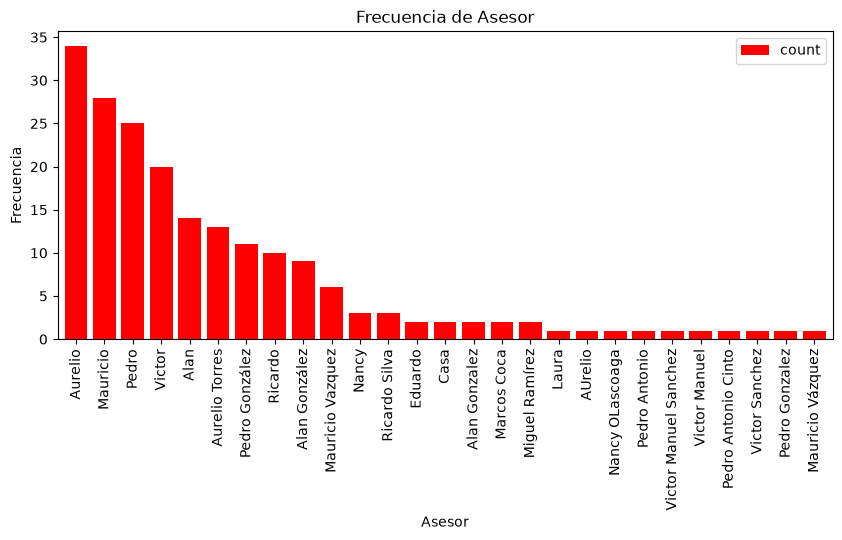

In [34]:
#Realizamos gráfico de barras de la variable 'Asesor'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Asesor')
plt.xlabel('Asesor')
plt.ylabel('Frecuencia')
plt.show()

In [35]:
#Obtengo un análisis univariado de la variable categórica 'Esatus Lead'
Tabla_freq = Bitacora['Esatus Lead'].value_counts().reset_index()
Tabla_freq

,Esatus Lead,count
0,Activo,168
1,Cerrado,18
2,Venta,7
3,Finalizado,4


In [36]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Esatus Lead')
Filtro_index

,count
Esatus Lead,
Activo,168
Cerrado,18
Venta,7
Finalizado,4


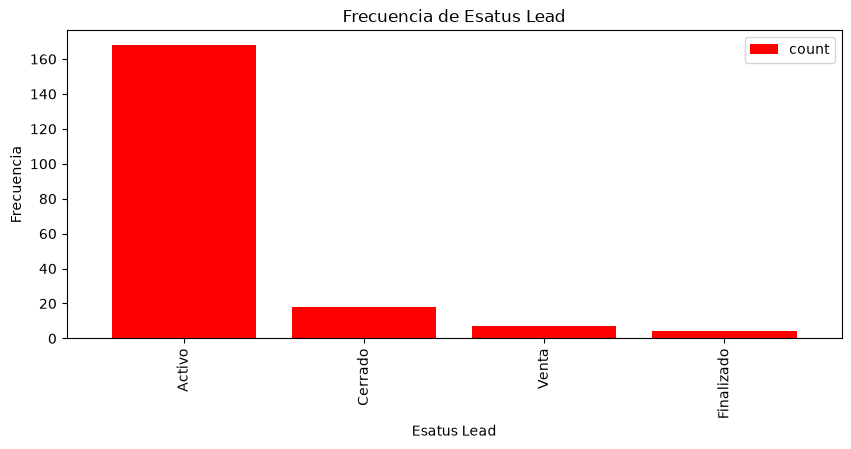

In [37]:
#Realizamos gráfico de barras de la variable 'Esatus Lead'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Esatus Lead')
plt.xlabel('Esatus Lead')
plt.ylabel('Frecuencia')
plt.show()

In [38]:
#VARIABLE PDM
#Obtengo un análisis univariado de la variable categórica 'PDM'
Tabla_freq = Bitacora['PDM'].value_counts().reset_index()
Tabla_freq

,PDM,count
0,False,159
1,True,75


In [39]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('PDM')
Filtro_index

,count
PDM,
False,159
True,75


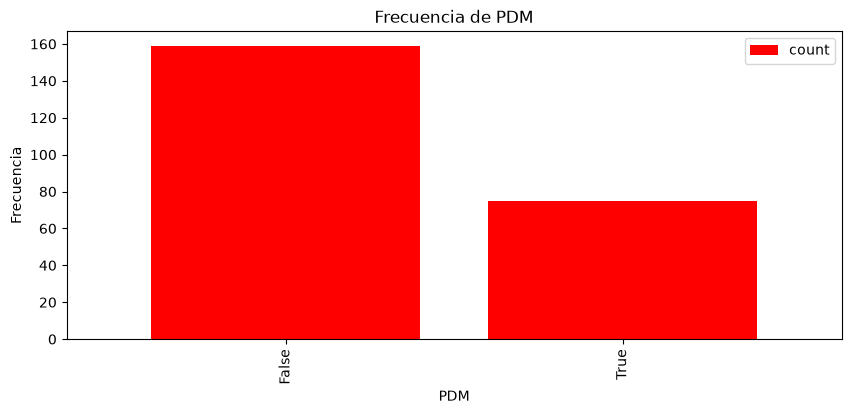

In [40]:
#Realizamos gráfico de barras de la variable 'PDM'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de PDM')
plt.xlabel('PDM')
plt.ylabel('Frecuencia')
plt.show()

In [41]:
#VARIABLE SDC
#Obtengo un análisis univariado de la variable categórica 'SDC'
Tabla_freq = Bitacora['SDC'].value_counts().reset_index()
Tabla_freq

,SDC,count
0,False,212
1,True,4


In [42]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('SDC')
Filtro_index

,count
SDC,
False,212
True,4


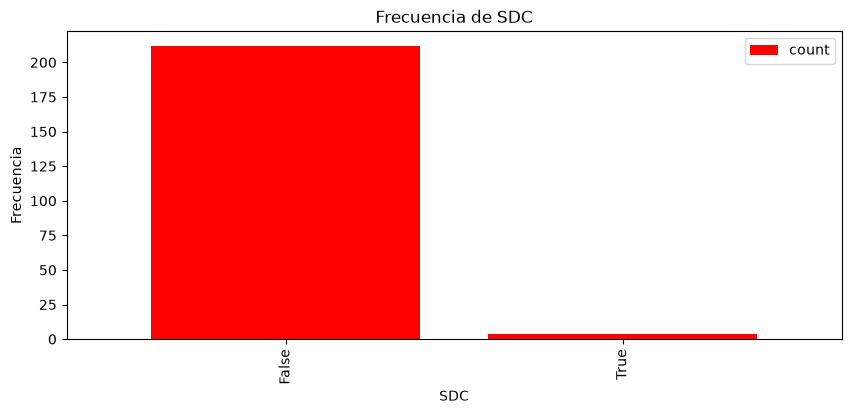

In [43]:
#Realizamos gráfico de barras de la variable 'SDC'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de SDC')
plt.xlabel('SDC')
plt.ylabel('Frecuencia')
plt.show()

In [44]:
#VARIABLE ESTAUS DE SDC
#Obtengo un análisis univariado de la variable categórica 'Estatus de SDC'
Tabla_freq = Bitacora['Estatus de SDC'].value_counts().reset_index()
Tabla_freq

,Estatus de SDC,count
0,Analisis,1
1,Rechazada,1


In [45]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Estatus de SDC')
Filtro_index

,count
Estatus de SDC,
Analisis,1
Rechazada,1


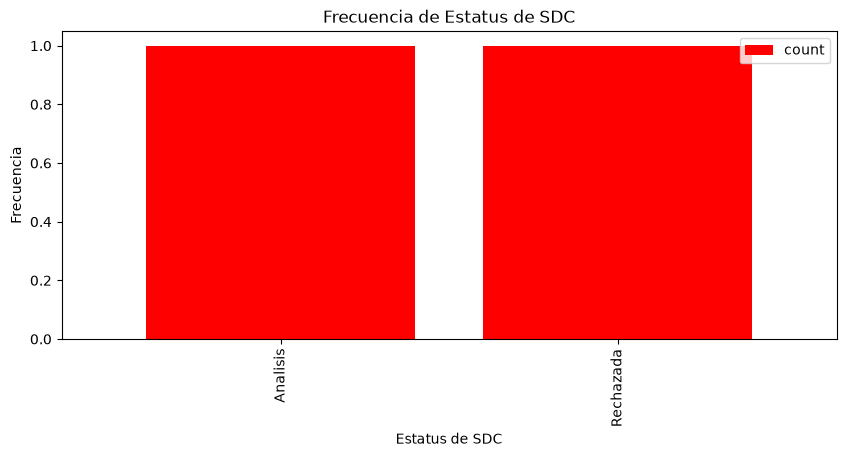

In [46]:
#Realizamos gráfico de barras de la variable 'Estatus de SDC'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Estatus de SDC')
plt.xlabel('Estatus de SDC')
plt.ylabel('Frecuencia')
plt.show()

In [47]:
#VARIABLE VENTA
#Obtengo un análisis univariado de la variable categórica 'Venta'
Tabla_freq = Bitacora['Venta'].value_counts().reset_index()
Tabla_freq

,Venta,count
0,False,212
1,True,4


In [48]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Venta')
Filtro_index

,count
Venta,
False,212
True,4


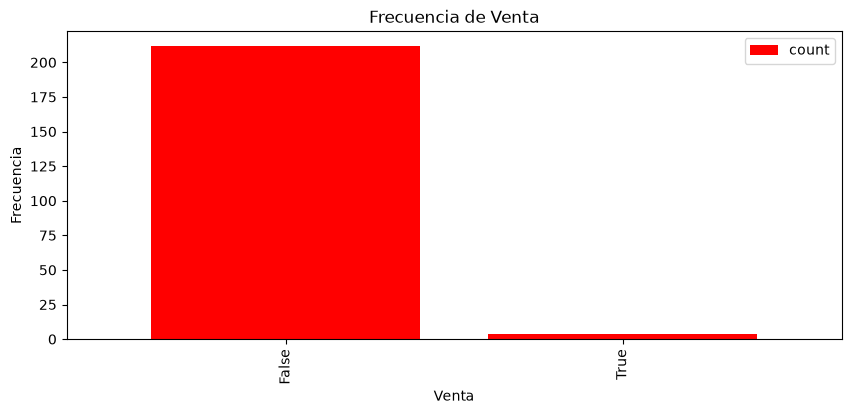

In [49]:
#Realizamos gráfico de barras de la variable 'Venta'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Venta')
plt.xlabel('Venta')
plt.ylabel('Frecuencia')
plt.show()

In [50]:
#VARIABLE TEMPERATURA
#Obtengo un análisis univariado de la variable categórica 'Temperatura'
Tabla_freq = Bitacora['Temperatura'].value_counts().reset_index()
Tabla_freq

,Temperatura,count
0,Lead InteresBajo,4
1,Lead Interes Alto,3
2,Lead Interes Medio,1
3,Ebullición,1
4,Tibio,1


In [51]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Temperatura')
Filtro_index

,count
Temperatura,
Lead InteresBajo,4
Lead Interes Alto,3
Lead Interes Medio,1
Ebullición,1
Tibio,1


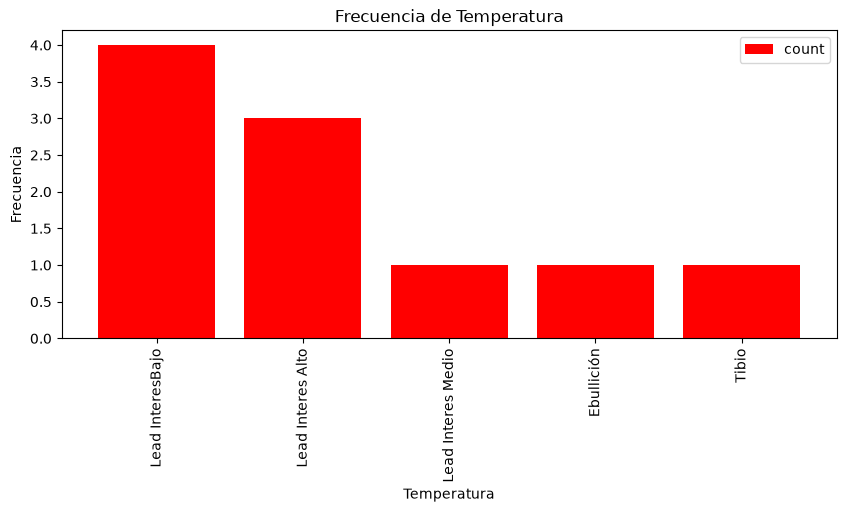

In [52]:
#Realizamos gráfico de barras de la variable 'Temperatura'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia')
plt.show()

In [53]:
#VARIABLE INTER GERENTE
#Obtengo un análisis univariado de la variable categórica 'Inter Gerente'
Tabla_freq = Bitacora['Inter Gerente'].value_counts().reset_index()
Tabla_freq

,Inter Gerente,count
0,False,185
1,True,31


In [54]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Inter Gerente')
Filtro_index

,count
Inter Gerente,
False,185
True,31


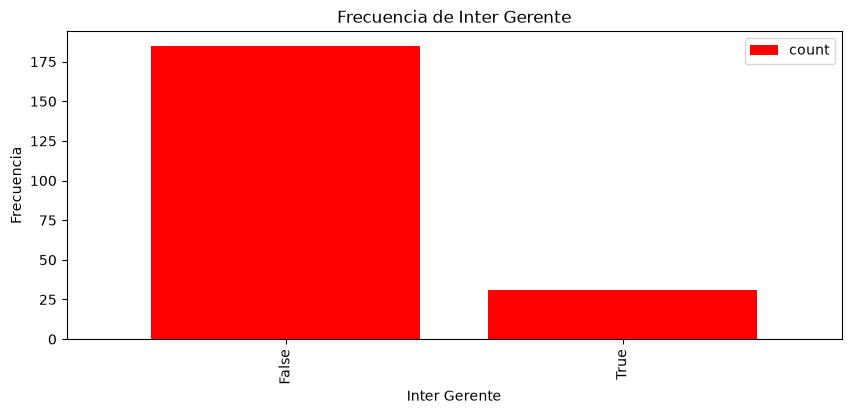

In [55]:
#Realizamos gráfico de barras de la variable 'Inter Gerente'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Inter Gerente')
plt.xlabel('Inter Gerente')
plt.ylabel('Frecuencia')
plt.show()

In [56]:
#VARIABLE MES
#Obtengo un análisis univariado de la variable categórica 'Mes'
Tabla_freq = Bitacora['Mes'].value_counts().reset_index()
Tabla_freq

,Mes,count
0,Mayo,65
1,Junio,59
2,Abril,46
3,Julio,27
4,Agosto,1


In [57]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Mes')
Filtro_index

,count
Mes,
Mayo,65
Junio,59
Abril,46
Julio,27
Agosto,1


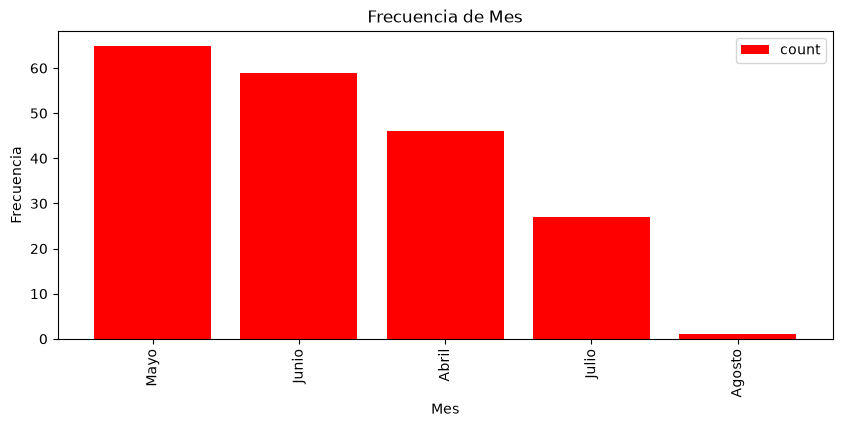

In [58]:
#Realizamos gráfico de barras de la variable 'Mes'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Mes')
plt.xlabel('Mes')
plt.ylabel('Frecuencia')
plt.show()

In [59]:
#VARIABLE DIA_SEMANA
#Obtengo un análisis univariado de la variable categórica 'Dia_Semana'
Tabla_freq = Bitacora['Dia_Semana'].value_counts().reset_index()
Tabla_freq

,Dia_Semana,count
0,Viernes,39
1,Sabado,31
2,Miercoles,29
3,Lunes,29
4,Martes,26
5,Jueves,25
6,Domingo,19


In [60]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Dia_Semana')
Filtro_index

,count
Dia_Semana,
Viernes,39
Sabado,31
Miercoles,29
Lunes,29
Martes,26
Jueves,25
Domingo,19


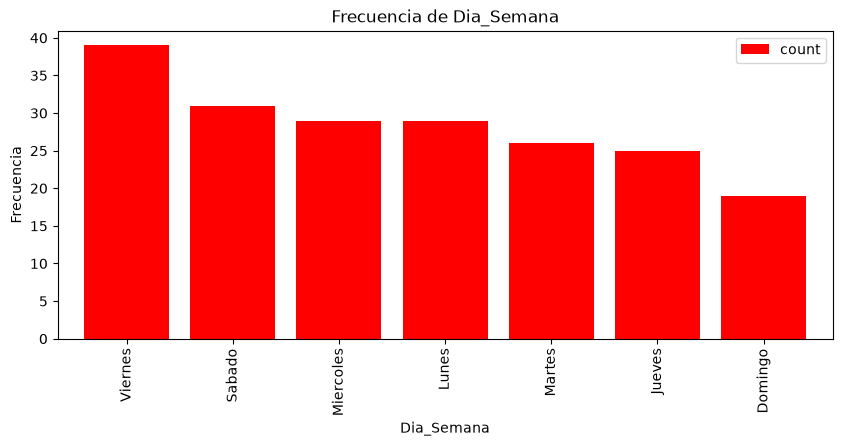

In [61]:
#Realizamos gráfico de barras de la variable 'Dia_Semana'
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='red')
plt.title('Frecuencia de Dia_Semana')
plt.xlabel('Dia_Semana')
plt.ylabel('Frecuencia')
plt.show()

In [62]:
#Categorización de variables (Leads Reales) — Regla de Sturges
#Corroboramos valores nulos en las variables a categorizar
valores_nulos = Leads[vars_leads].isnull().sum()
valores_nulos

Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [63]:
#Calculamos el numero total de la población 'n' (número de meses con datos)
n = Leads.shape[0]
n

28

In [64]:
#Calculamos el número de Intervalos de Clase 'ni', aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni_clases = int(np.ceil(ni))
ni, ni_clases

(np.float64(5.8045646640561674), 6)

In [65]:
#VARIABLE TOTAL
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Total'].max()
Min = Leads['Total'].min()
Limites = [Min, Max]
Limites

[np.float64(178.0), np.float64(1973.0)]

In [66]:
#Calculamos el rango R
R = Max - Min
R

np.float64(1795.0)

In [67]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(299.1666666666667)

In [68]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([ 177.70083333,  476.96722222,  776.23361111, 1075.5       ,
       1374.76638889, 1674.03277778, 1973.29916667])

In [69]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (177.7 - 477.0)',
 'Categoria2 (477.0 - 776.2)',
 'Categoria3 (776.2 - 1075.5)',
 'Categoria4 (1075.5 - 1374.8)',
 'Categoria5 (1374.8 - 1674.0)',
 'Categoria6 (1674.0 - 1973.3)']

In [70]:
#Categorizamos la variable numérica en clases
Leads['Total_Cat'] = pd.cut(Leads['Total'], bins=intervalos, labels=categorias)
Leads[['Total','Total_Cat']]

,Total,Total_Cat
0,543.0,Categoria2 (477.0 - 776.2)
1,178.0,Categoria1 (177.7 - 477.0)
2,416.0,Categoria1 (177.7 - 477.0)
3,422.0,Categoria1 (177.7 - 477.0)
4,967.0,Categoria3 (776.2 - 1075.5)
5,954.0,Categoria3 (776.2 - 1075.5)
6,1409.0,Categoria5 (1374.8 - 1674.0)
7,1315.0,Categoria4 (1075.5 - 1374.8)
8,1973.0,Categoria6 (1674.0 - 1973.3)
9,1562.0,Categoria5 (1374.8 - 1674.0)


In [71]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Total_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Total_Cat,count
0,Categoria1 (177.7 - 477.0),3
1,Categoria2 (477.0 - 776.2),2
2,Categoria3 (776.2 - 1075.5),6
3,Categoria4 (1075.5 - 1374.8),9
4,Categoria5 (1374.8 - 1674.0),6
5,Categoria6 (1674.0 - 1973.3),2


In [72]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Total_Cat')
Filtro_index

,count
Total_Cat,
Categoria1 (177.7 - 477.0),3
Categoria2 (477.0 - 776.2),2
Categoria3 (776.2 - 1075.5),6
Categoria4 (1075.5 - 1374.8),9
Categoria5 (1374.8 - 1674.0),6
Categoria6 (1674.0 - 1973.3),2


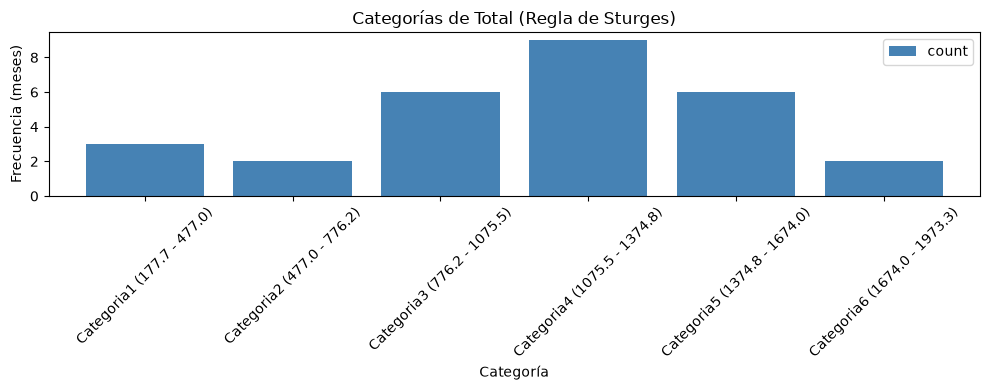

In [73]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Total (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [74]:
# VARIABLE ILOCALIZABLE
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Ilocalizable'].max()
Min = Leads['Ilocalizable'].min()
Limites = [Min, Max]
Limites

[np.float64(5.0), np.float64(514.0)]

In [75]:
#Calculamos el rango R
R = Max - Min
R

np.float64(509.0)

In [76]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(84.83333333333333)

In [77]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([  4.91516667,  89.77677778, 174.63838889, 259.5       ,
       344.36161111, 429.22322222, 514.08483333])

In [78]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (4.9 - 89.8)',
 'Categoria2 (89.8 - 174.6)',
 'Categoria3 (174.6 - 259.5)',
 'Categoria4 (259.5 - 344.4)',
 'Categoria5 (344.4 - 429.2)',
 'Categoria6 (429.2 - 514.1)']

In [79]:
#Categorizamos la variable numérica en clases
Leads['Ilocalizable_Cat'] = pd.cut(Leads['Ilocalizable'], bins=intervalos, labels=categorias)
Leads[['Ilocalizable','Ilocalizable_Cat']]

,Ilocalizable,Ilocalizable_Cat
0,108.0,Categoria2 (89.8 - 174.6)
1,37.0,Categoria1 (4.9 - 89.8)
2,79.0,Categoria1 (4.9 - 89.8)
3,33.0,Categoria1 (4.9 - 89.8)
4,140.0,Categoria2 (89.8 - 174.6)
5,112.0,Categoria2 (89.8 - 174.6)
6,504.0,Categoria6 (429.2 - 514.1)
7,431.0,Categoria6 (429.2 - 514.1)
8,514.0,Categoria6 (429.2 - 514.1)
9,153.0,Categoria2 (89.8 - 174.6)


In [80]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Ilocalizable_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Ilocalizable_Cat,count
0,Categoria1 (4.9 - 89.8),13
1,Categoria2 (89.8 - 174.6),9
2,Categoria3 (174.6 - 259.5),2
3,Categoria4 (259.5 - 344.4),0
4,Categoria5 (344.4 - 429.2),1
5,Categoria6 (429.2 - 514.1),3


In [81]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Ilocalizable_Cat')
Filtro_index

,count
Ilocalizable_Cat,
Categoria1 (4.9 - 89.8),13
Categoria2 (89.8 - 174.6),9
Categoria3 (174.6 - 259.5),2
Categoria4 (259.5 - 344.4),0
Categoria5 (344.4 - 429.2),1
Categoria6 (429.2 - 514.1),3


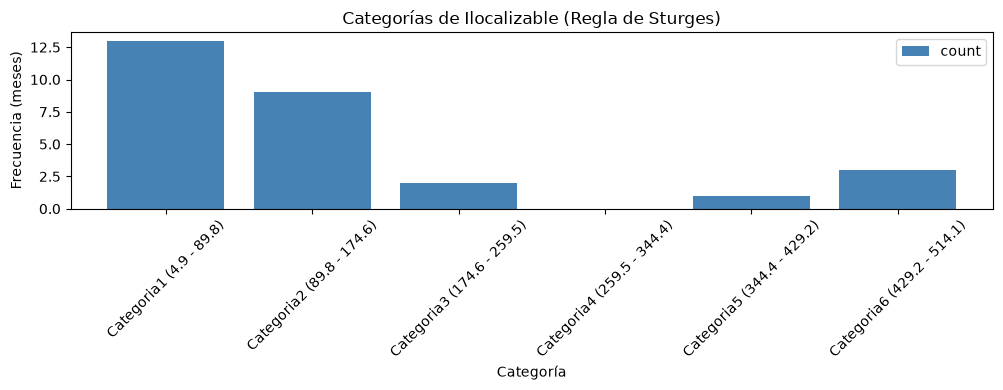

In [82]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Ilocalizable (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [83]:
#VARIABLE NO CONTESTA
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['No Contesta'].max()
Min = Leads['No Contesta'].min()
Limites = [Min, Max]
Limites

[np.float64(13.0), np.float64(606.0)]

In [84]:
#Calculamos el rango R
R = Max - Min
R

np.float64(593.0)

In [85]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(98.83333333333333)

In [86]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([ 12.90116667, 111.76744444, 210.63372222, 309.5       ,
       408.36627778, 507.23255556, 606.09883333])

In [87]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (12.9 - 111.8)',
 'Categoria2 (111.8 - 210.6)',
 'Categoria3 (210.6 - 309.5)',
 'Categoria4 (309.5 - 408.4)',
 'Categoria5 (408.4 - 507.2)',
 'Categoria6 (507.2 - 606.1)']

In [88]:
#Categorizamos la variable numérica en clases
Leads['No Contesta_Cat'] = pd.cut(Leads['No Contesta'], bins=intervalos, labels=categorias)
Leads[['No Contesta','No Contesta_Cat']]

,No Contesta,No Contesta_Cat
0,33.0,Categoria1 (12.9 - 111.8)
1,13.0,Categoria1 (12.9 - 111.8)
2,46.0,Categoria1 (12.9 - 111.8)
3,100.0,Categoria1 (12.9 - 111.8)
4,173.0,Categoria2 (111.8 - 210.6)
5,251.0,Categoria3 (210.6 - 309.5)
6,324.0,Categoria4 (309.5 - 408.4)
7,314.0,Categoria4 (309.5 - 408.4)
8,606.0,Categoria6 (507.2 - 606.1)
9,321.0,Categoria4 (309.5 - 408.4)


In [89]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['No Contesta_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,No Contesta_Cat,count
0,Categoria1 (12.9 - 111.8),9
1,Categoria2 (111.8 - 210.6),8
2,Categoria3 (210.6 - 309.5),4
3,Categoria4 (309.5 - 408.4),4
4,Categoria5 (408.4 - 507.2),1
5,Categoria6 (507.2 - 606.1),2


In [90]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('No Contesta_Cat')
Filtro_index

,count
No Contesta_Cat,
Categoria1 (12.9 - 111.8),9
Categoria2 (111.8 - 210.6),8
Categoria3 (210.6 - 309.5),4
Categoria4 (309.5 - 408.4),4
Categoria5 (408.4 - 507.2),1
Categoria6 (507.2 - 606.1),2


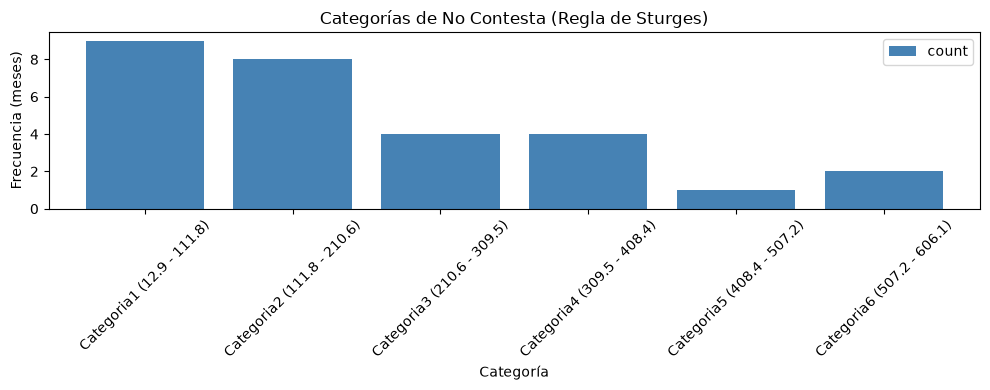

In [91]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de No Contesta (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [92]:
#VARIABLE D.INCORRECTOS
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['D. Incorrectos'].max()
Min = Leads['D. Incorrectos'].min()
Limites = [Min, Max]
Limites

[np.float64(0.0), np.float64(62.0)]

In [93]:
#Calculamos el rango R
R = Max - Min
R

np.float64(62.0)

In [94]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(10.333333333333334)

In [95]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([-1.03333333e-02,  1.03264444e+01,  2.06632222e+01,  3.10000000e+01,
        4.13367778e+01,  5.16735556e+01,  6.20103333e+01])

In [96]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (-0.0 - 10.3)',
 'Categoria2 (10.3 - 20.7)',
 'Categoria3 (20.7 - 31.0)',
 'Categoria4 (31.0 - 41.3)',
 'Categoria5 (41.3 - 51.7)',
 'Categoria6 (51.7 - 62.0)']

In [97]:
#Categorizamos la variable numérica en clases
Leads['D. Incorrectos_Cat'] = pd.cut(Leads['D. Incorrectos'], bins=intervalos, labels=categorias)
Leads[['D. Incorrectos','D. Incorrectos_Cat']]

,D. Incorrectos,D. Incorrectos_Cat
0,0.0,Categoria1 (-0.0 - 10.3)
1,0.0,Categoria1 (-0.0 - 10.3)
2,3.0,Categoria1 (-0.0 - 10.3)
3,17.0,Categoria2 (10.3 - 20.7)
4,31.0,Categoria3 (20.7 - 31.0)
5,12.0,Categoria2 (10.3 - 20.7)
6,17.0,Categoria2 (10.3 - 20.7)
7,14.0,Categoria2 (10.3 - 20.7)
8,18.0,Categoria2 (10.3 - 20.7)
9,44.0,Categoria5 (41.3 - 51.7)


In [98]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['D. Incorrectos_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,D. Incorrectos_Cat,count
0,Categoria1 (-0.0 - 10.3),13
1,Categoria2 (10.3 - 20.7),6
2,Categoria3 (20.7 - 31.0),2
3,Categoria4 (31.0 - 41.3),2
4,Categoria5 (41.3 - 51.7),2
5,Categoria6 (51.7 - 62.0),3


In [99]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('D. Incorrectos_Cat')
Filtro_index

,count
D. Incorrectos_Cat,
Categoria1 (-0.0 - 10.3),13
Categoria2 (10.3 - 20.7),6
Categoria3 (20.7 - 31.0),2
Categoria4 (31.0 - 41.3),2
Categoria5 (41.3 - 51.7),2
Categoria6 (51.7 - 62.0),3


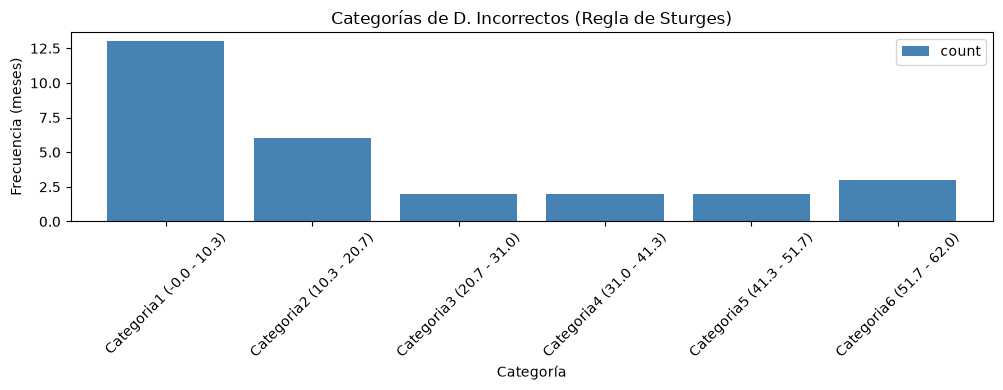

In [100]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de D. Incorrectos (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [101]:
#VARIABLE DUPLICADOS
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Duplicados'].max()
Min = Leads['Duplicados'].min()
Limites = [Min, Max]
Limites

[np.float64(0.0), np.float64(136.0)]

In [102]:
#Calculamos el rango R
R = Max - Min
R

np.float64(136.0)

In [103]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(22.666666666666668)

In [104]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([-2.26666667e-02,  2.26515556e+01,  4.53257778e+01,  6.80000000e+01,
        9.06742222e+01,  1.13348444e+02,  1.36022667e+02])

In [105]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (-0.0 - 22.7)',
 'Categoria2 (22.7 - 45.3)',
 'Categoria3 (45.3 - 68.0)',
 'Categoria4 (68.0 - 90.7)',
 'Categoria5 (90.7 - 113.3)',
 'Categoria6 (113.3 - 136.0)']

In [106]:
#Categorizamos la variable numérica en clases
Leads['Duplicados_Cat'] = pd.cut(Leads['Duplicados'], bins=intervalos, labels=categorias)
Leads[['Duplicados','Duplicados_Cat']]

,Duplicados,Duplicados_Cat
0,1.0,Categoria1 (-0.0 - 22.7)
1,0.0,Categoria1 (-0.0 - 22.7)
2,0.0,Categoria1 (-0.0 - 22.7)
3,0.0,Categoria1 (-0.0 - 22.7)
4,3.0,Categoria1 (-0.0 - 22.7)
5,9.0,Categoria1 (-0.0 - 22.7)
6,18.0,Categoria1 (-0.0 - 22.7)
7,26.0,Categoria2 (22.7 - 45.3)
8,13.0,Categoria1 (-0.0 - 22.7)
9,4.0,Categoria1 (-0.0 - 22.7)


In [107]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Duplicados_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Duplicados_Cat,count
0,Categoria1 (-0.0 - 22.7),13
1,Categoria2 (22.7 - 45.3),6
2,Categoria3 (45.3 - 68.0),6
3,Categoria4 (68.0 - 90.7),1
4,Categoria5 (90.7 - 113.3),1
5,Categoria6 (113.3 - 136.0),1


In [108]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Duplicados_Cat')
Filtro_index

,count
Duplicados_Cat,
Categoria1 (-0.0 - 22.7),13
Categoria2 (22.7 - 45.3),6
Categoria3 (45.3 - 68.0),6
Categoria4 (68.0 - 90.7),1
Categoria5 (90.7 - 113.3),1
Categoria6 (113.3 - 136.0),1


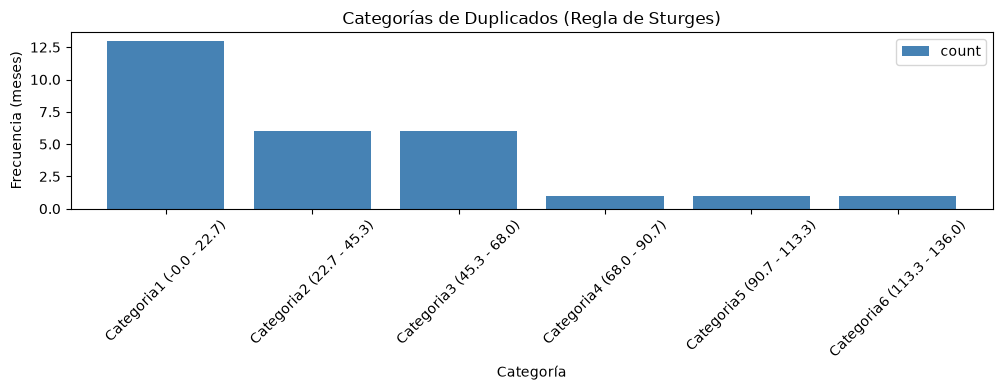

In [109]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Duplicados (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [110]:
#VARIABLE EFECTIVOS
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Efectivos'].max()
Min = Leads['Efectivos'].min()
Limites = [Min, Max]
Limites

[np.float64(128.0), np.float64(1040.0)]

In [111]:
#Calculamos el rango R
R = Max - Min
R

np.float64(912.0)

In [112]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(152.0)

In [113]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([ 127.848     ,  279.89866667,  431.94933333,  584.        ,
        736.05066667,  888.10133333, 1040.152     ])

In [114]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (127.8 - 279.9)',
 'Categoria2 (279.9 - 431.9)',
 'Categoria3 (431.9 - 584.0)',
 'Categoria4 (584.0 - 736.1)',
 'Categoria5 (736.1 - 888.1)',
 'Categoria6 (888.1 - 1040.2)']

In [115]:
#Categorizamos la variable numérica en clases
Leads['Efectivos_Cat'] = pd.cut(Leads['Efectivos'], bins=intervalos, labels=categorias)
Leads[['Efectivos','Efectivos_Cat']]

,Efectivos,Efectivos_Cat
0,389.0,Categoria2 (279.9 - 431.9)
1,128.0,Categoria1 (127.8 - 279.9)
2,288.0,Categoria2 (279.9 - 431.9)
3,274.0,Categoria1 (127.8 - 279.9)
4,620.0,Categoria4 (584.0 - 736.1)
5,570.0,Categoria3 (431.9 - 584.0)
6,546.0,Categoria3 (431.9 - 584.0)
7,530.0,Categoria3 (431.9 - 584.0)
8,822.0,Categoria5 (736.1 - 888.1)
9,1040.0,Categoria6 (888.1 - 1040.2)


In [116]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Efectivos_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Efectivos_Cat,count
0,Categoria1 (127.8 - 279.9),2
1,Categoria2 (279.9 - 431.9),2
2,Categoria3 (431.9 - 584.0),5
3,Categoria4 (584.0 - 736.1),12
4,Categoria5 (736.1 - 888.1),3
5,Categoria6 (888.1 - 1040.2),4


In [117]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Efectivos_Cat')
Filtro_index

,count
Efectivos_Cat,
Categoria1 (127.8 - 279.9),2
Categoria2 (279.9 - 431.9),2
Categoria3 (431.9 - 584.0),5
Categoria4 (584.0 - 736.1),12
Categoria5 (736.1 - 888.1),3
Categoria6 (888.1 - 1040.2),4


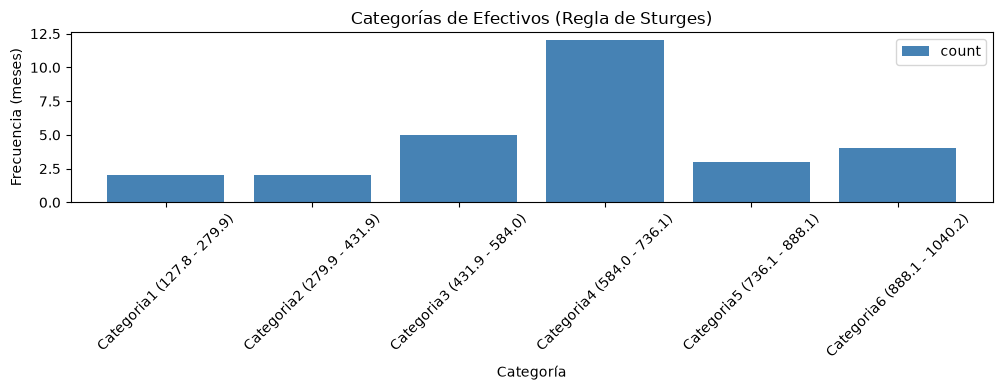

In [118]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Efectivos (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [119]:
#VARIABLE ABIERTOS
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Abiertos'].max()
Min = Leads['Abiertos'].min()
Limites = [Min, Max]
Limites

[np.float64(1.0), np.float64(823.0)]

In [120]:
#Calculamos el rango R
R = Max - Min
R

np.float64(822.0)

In [121]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(137.0)

In [122]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([  0.863     , 137.90866667, 274.95433333, 412.        ,
       549.04566667, 686.09133333, 823.137     ])

In [123]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (0.9 - 137.9)',
 'Categoria2 (137.9 - 275.0)',
 'Categoria3 (275.0 - 412.0)',
 'Categoria4 (412.0 - 549.0)',
 'Categoria5 (549.0 - 686.1)',
 'Categoria6 (686.1 - 823.1)']

In [124]:
#Categorizamos la variable numérica en clases
Leads['Abiertos_Cat'] = pd.cut(Leads['Abiertos'], bins=intervalos, labels=categorias)
Leads[['Abiertos','Abiertos_Cat']]

,Abiertos,Abiertos_Cat
0,1.0,Categoria1 (0.9 - 137.9)
1,1.0,Categoria1 (0.9 - 137.9)
2,1.0,Categoria1 (0.9 - 137.9)
3,5.0,Categoria1 (0.9 - 137.9)
4,17.0,Categoria1 (0.9 - 137.9)
5,5.0,Categoria1 (0.9 - 137.9)
6,22.0,Categoria1 (0.9 - 137.9)
7,42.0,Categoria1 (0.9 - 137.9)
8,72.0,Categoria1 (0.9 - 137.9)
9,79.0,Categoria1 (0.9 - 137.9)


In [125]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Abiertos_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Abiertos_Cat,count
0,Categoria1 (0.9 - 137.9),11
1,Categoria2 (137.9 - 275.0),5
2,Categoria3 (275.0 - 412.0),5
3,Categoria4 (412.0 - 549.0),3
4,Categoria5 (549.0 - 686.1),2
5,Categoria6 (686.1 - 823.1),2


In [126]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Abiertos_Cat')
Filtro_index

,count
Abiertos_Cat,
Categoria1 (0.9 - 137.9),11
Categoria2 (137.9 - 275.0),5
Categoria3 (275.0 - 412.0),5
Categoria4 (412.0 - 549.0),3
Categoria5 (549.0 - 686.1),2
Categoria6 (686.1 - 823.1),2


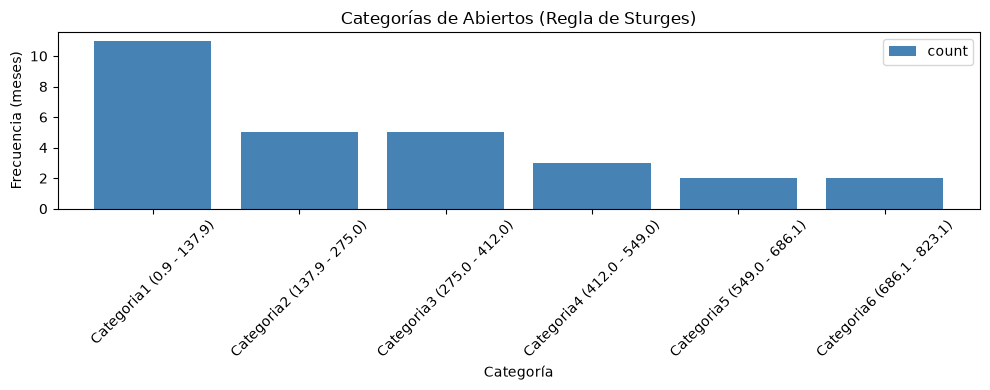

In [127]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Abiertos (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [128]:
#VARIABLE VENTAS 
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Ventas'].max()
Min = Leads['Ventas'].min()
Limites = [Min, Max]
Limites

[np.float64(6.0), np.float64(41.0)]

In [129]:
#Calculamos el rango R
R = Max - Min
R

np.float64(35.0)

In [130]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(5.833333333333333)

In [131]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([ 5.99416667, 11.82944444, 17.66472222, 23.5       , 29.33527778,
       35.17055556, 41.00583333])

In [132]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (6.0 - 11.8)',
 'Categoria2 (11.8 - 17.7)',
 'Categoria3 (17.7 - 23.5)',
 'Categoria4 (23.5 - 29.3)',
 'Categoria5 (29.3 - 35.2)',
 'Categoria6 (35.2 - 41.0)']

In [133]:
#Categorizamos la variable numérica en clases
Leads['Ventas_Cat'] = pd.cut(Leads['Ventas'], bins=intervalos, labels=categorias)
Leads[['Ventas','Ventas_Cat']]

,Ventas,Ventas_Cat
0,12.0,Categoria2 (11.8 - 17.7)
1,7.0,Categoria1 (6.0 - 11.8)
2,8.0,Categoria1 (6.0 - 11.8)
3,13.0,Categoria2 (11.8 - 17.7)
4,6.0,Categoria1 (6.0 - 11.8)
5,21.0,Categoria3 (17.7 - 23.5)
6,17.0,Categoria2 (11.8 - 17.7)
7,17.0,Categoria2 (11.8 - 17.7)
8,23.0,Categoria3 (17.7 - 23.5)
9,22.0,Categoria3 (17.7 - 23.5)


In [134]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Ventas_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Ventas_Cat,count
0,Categoria1 (6.0 - 11.8),3
1,Categoria2 (11.8 - 17.7),4
2,Categoria3 (17.7 - 23.5),4
3,Categoria4 (23.5 - 29.3),2
4,Categoria5 (29.3 - 35.2),7
5,Categoria6 (35.2 - 41.0),8


In [135]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Ventas_Cat')
Filtro_index

,count
Ventas_Cat,
Categoria1 (6.0 - 11.8),3
Categoria2 (11.8 - 17.7),4
Categoria3 (17.7 - 23.5),4
Categoria4 (23.5 - 29.3),2
Categoria5 (29.3 - 35.2),7
Categoria6 (35.2 - 41.0),8


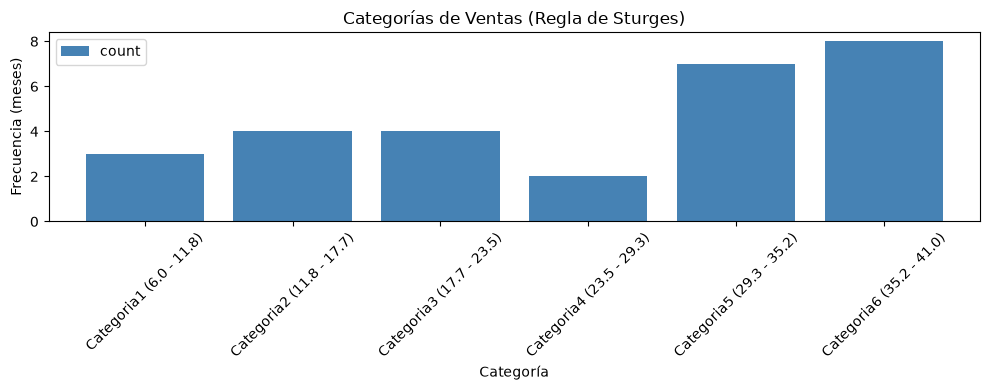

In [136]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Ventas (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [137]:
#VARIABLE CONVENSION 
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Conversion'].max()
Min = Leads['Conversion'].min()
Limites = [Min, Max]
Limites

[np.float64(1.0), np.float64(5.9)]

In [138]:
#Calculamos el rango R
R = Max - Min
R

np.float64(4.9)

In [139]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(0.8166666666666668)

In [140]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([0.99918333, 1.81612222, 2.63306111, 3.45      , 4.26693889,
       5.08387778, 5.90081667])

In [141]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (1.0 - 1.8)',
 'Categoria2 (1.8 - 2.6)',
 'Categoria3 (2.6 - 3.4)',
 'Categoria4 (3.4 - 4.3)',
 'Categoria5 (4.3 - 5.1)',
 'Categoria6 (5.1 - 5.9)']

In [142]:
#Categorizamos la variable numérica en clases
Leads['Conversion_Cat'] = pd.cut(Leads['Conversion'], bins=intervalos, labels=categorias)
Leads[['Conversion','Conversion_Cat']]

,Conversion,Conversion_Cat
0,3.1,Categoria3 (2.6 - 3.4)
1,5.5,Categoria6 (5.1 - 5.9)
2,2.8,Categoria3 (2.6 - 3.4)
3,4.7,Categoria5 (4.3 - 5.1)
4,1.0,Categoria1 (1.0 - 1.8)
5,3.7,Categoria4 (3.4 - 4.3)
6,3.1,Categoria3 (2.6 - 3.4)
7,3.2,Categoria3 (2.6 - 3.4)
8,2.8,Categoria3 (2.6 - 3.4)
9,2.1,Categoria2 (1.8 - 2.6)


In [143]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Conversion_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Conversion_Cat,count
0,Categoria1 (1.0 - 1.8),1
1,Categoria2 (1.8 - 2.6),1
2,Categoria3 (2.6 - 3.4),7
3,Categoria4 (3.4 - 4.3),7
4,Categoria5 (4.3 - 5.1),4
5,Categoria6 (5.1 - 5.9),8


In [144]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Conversion_Cat')
Filtro_index

,count
Conversion_Cat,
Categoria1 (1.0 - 1.8),1
Categoria2 (1.8 - 2.6),1
Categoria3 (2.6 - 3.4),7
Categoria4 (3.4 - 4.3),7
Categoria5 (4.3 - 5.1),4
Categoria6 (5.1 - 5.9),8


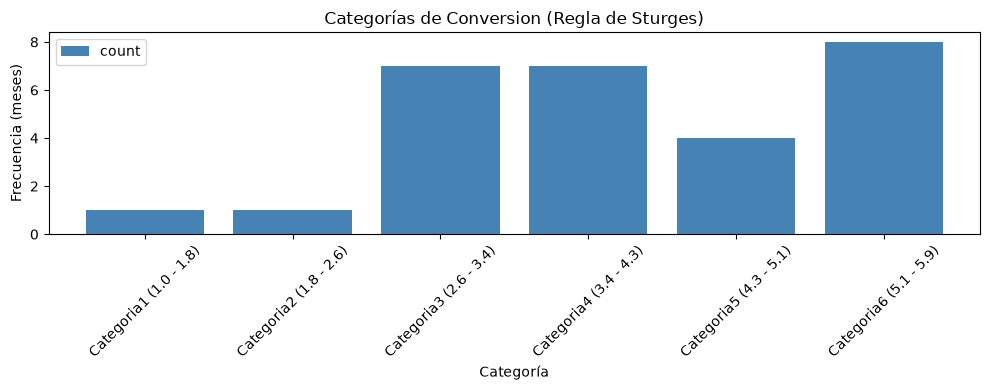

In [145]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Conversion (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()

In [146]:
#VARIABLE EFECTIVIDAD DE LEADS
#Obtenemos el limite superior e inferior de la columna objetivo
Max = Leads['Efectividad de Leads'].max()
Min = Leads['Efectividad de Leads'].min()
Limites = [Min, Max]
Limites

[np.float64(39.0), np.float64(83.0)]

In [147]:
#Calculamos el rango R
R = Max - Min
R

np.float64(44.0)

In [148]:
#Calculamos el Ancho del Intervalo 'i'
i = R/ni_clases
i

np.float64(7.333333333333333)

In [149]:
#Construimos los intervalos, ampliando ligeramente los límites para incluir todos los valores
intervalos = np.linspace(Min - i*0.001, Max + i*0.001, ni_clases + 1)
intervalos

array([38.99266667, 46.32844444, 53.66422222, 61.        , 68.33577778,
       75.67155556, 83.00733333])

In [150]:
#Creamos las etiquetas de categoría a partir de los intervalos
categorias = [f'Categoria{k+1} ({intervalos[k]:.1f} - {intervalos[k+1]:.1f})' for k in range(ni_clases)]
categorias

['Categoria1 (39.0 - 46.3)',
 'Categoria2 (46.3 - 53.7)',
 'Categoria3 (53.7 - 61.0)',
 'Categoria4 (61.0 - 68.3)',
 'Categoria5 (68.3 - 75.7)',
 'Categoria6 (75.7 - 83.0)']

In [151]:
#Categorizamos la variable numérica en clases
Leads['Efectividad de Leads_Cat'] = pd.cut(Leads['Efectividad de Leads'], bins=intervalos, labels=categorias)
Leads[['Efectividad de Leads','Efectividad de Leads_Cat']]

,Efectividad de Leads,Efectividad de Leads_Cat
0,72.0,Categoria5 (68.3 - 75.7)
1,72.0,Categoria5 (68.3 - 75.7)
2,69.0,Categoria5 (68.3 - 75.7)
3,65.0,Categoria4 (61.0 - 68.3)
4,64.0,Categoria4 (61.0 - 68.3)
5,60.0,Categoria3 (53.7 - 61.0)
6,39.0,Categoria1 (39.0 - 46.3)
7,40.0,Categoria1 (39.0 - 46.3)
8,42.0,Categoria1 (39.0 - 46.3)
9,67.0,Categoria4 (61.0 - 68.3)


In [152]:
#Obtengo un análisis univariado de la variable ya categorizada
Tabla_freq = Leads['Efectividad de Leads_Cat'].value_counts().sort_index().reset_index()
Tabla_freq

,Efectividad de Leads_Cat,count
0,Categoria1 (39.0 - 46.3),3
1,Categoria2 (46.3 - 53.7),5
2,Categoria3 (53.7 - 61.0),5
3,Categoria4 (61.0 - 68.3),5
4,Categoria5 (68.3 - 75.7),7
5,Categoria6 (75.7 - 83.0),3


In [153]:
#Ajusto el indice de mi dataframe
Filtro_index = Tabla_freq.set_index('Efectividad de Leads_Cat')
Filtro_index

,count
Efectividad de Leads_Cat,
Categoria1 (39.0 - 46.3),3
Categoria2 (46.3 - 53.7),5
Categoria3 (53.7 - 61.0),5
Categoria4 (61.0 - 68.3),5
Categoria5 (68.3 - 75.7),7
Categoria6 (75.7 - 83.0),3


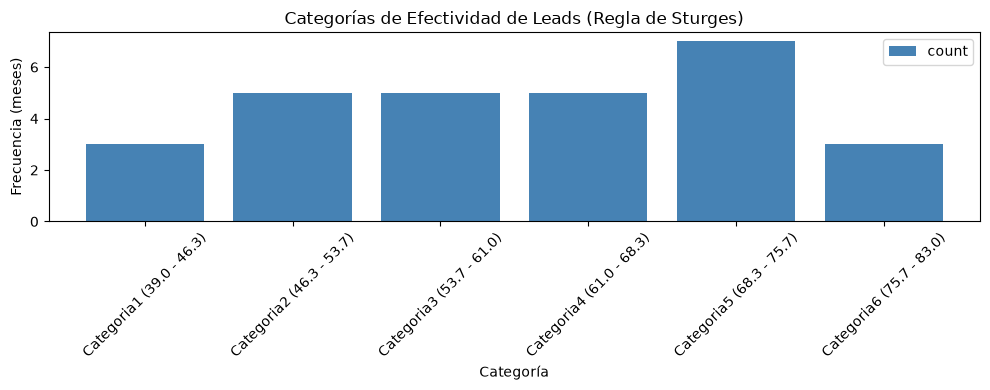

In [154]:
#Realizamos gráfico de barras de las categorías obtenidas
Filtro_index.plot(kind='bar', width=0.8, figsize=(10,4), color='steelblue', rot=45)
plt.title('Categorías de Efectividad de Leads (Regla de Sturges)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia (meses)')
plt.tight_layout()
plt.show()